In [2]:
import pandas as pd

# Load datasets
woolworths = pd.read_csv(r'C:\Users\Soham Tamhane\OneDrive\Desktop\Applied Software Engineering\Project\Woolworths_Cleaned.csv')
aldi = pd.read_csv(r'C:\Users\Soham Tamhane\OneDrive\Desktop\Applied Software Engineering\Project\Aldi_Cleaned.csv')
coles = pd.read_csv(r'C:\Users\Soham Tamhane\OneDrive\Desktop\Applied Software Engineering\Project\Coles_Cleaned.csv')
iga = pd.read_csv(r'C:\Users\Soham Tamhane\OneDrive\Desktop\Applied Software Engineering\Project\IGA_Cleaned.csv')

# Display first few rows
print(woolworths.head())
print(aldi.head())
print(coles.head())
print(iga.head())


      SKU                                 Brand_Product_Size  \
0  814139          Em Wholefoods Hemp Oil Cold Pressed 250mL   
1   84972  Happy Little Camper Newborn Natural Nappies 36...   
2   95412            Spc Spaghetti Rich Tomato 140g x12 pack   
3   99040               Mint Glazed Antipasto Dish Blue each   
4  808305                Seedlip Grove 42 Alcohol Free 700mL   

                 Brand                                 Product Name  \
0        em wholefoods          Em Wholefoods Hemp Oil Cold Pressed   
1  happy little camper  Happy Little Camper Newborn Natural Nappies   
2                  spc                    Spc Spaghetti Rich Tomato   
3                 mint              Mint Glazed Antipasto Dish Blue   
4              seedlip                Seedlip Grove 42 Alcohol Free   

   WOW Price       WOW Size        WOW ppu WOW Specials WOW Category  \
0      19.95          250mL  $7.98 / 100ML          NaN       Pantry   
1      14.00        36 pack    $0.39 / 1EA  

In [5]:
print(woolworths.columns)
print(aldi.columns)
print(coles.columns)
print(iga.columns)


Index(['SKU', 'Brand_Product_Size', 'Brand', 'Product Name', 'WOW Price',
       'WOW Size', 'WOW ppu', 'WOW Specials', 'WOW Category', 'Online Only',
       'New Product', 'Product URL', 'Store'],
      dtype='object')
Index(['Product Name', 'Price', 'Unit Price', 'Aldi Category', 'URL', 'Store'], dtype='object')
Index(['SKU', 'Brand_Product_Size', 'Brand', 'Product Name', 'COL Price',
       'COL ppu', 'COL Size', 'COL Specials', 'COL Category', 'Product URL',
       'Store'],
      dtype='object')
Index(['SKU', 'Brand_Product_Size', 'IGA Price', 'IGA ppu', 'IGA Category',
       'Product URL', 'Store'],
      dtype='object')


In [6]:
# Rename 'Product Name' or relevant columns to 'Product' across datasets
woolworths.rename(columns={'Product Name': 'Product', 'WOW Price': 'Price'}, inplace=True)
aldi.rename(columns={'Product Name': 'Product'}, inplace=True)
coles.rename(columns={'Product Name': 'Product', 'COL Price': 'Price'}, inplace=True)
iga.rename(columns={'Brand_Product_Size': 'Product','IGA Price': 'Price'}, inplace=True)


In [7]:
# Select only the required columns
woolworths = woolworths[['Product', 'Price', 'Store']]
aldi = aldi[['Product', 'Price', 'Store']]
coles = coles[['Product', 'Price', 'Store']]
iga = iga[['Product', 'Price', 'Store']]


In [8]:
# Combine datasets into one
combined = pd.concat([woolworths, aldi, coles, iga], ignore_index=True)


In [9]:
print(combined.head())
print(combined.columns)


                                       Product  Price       Store
0          Em Wholefoods Hemp Oil Cold Pressed  19.95  Woolworths
1  Happy Little Camper Newborn Natural Nappies   14.0  Woolworths
2                    Spc Spaghetti Rich Tomato   10.5  Woolworths
3              Mint Glazed Antipasto Dish Blue    2.0  Woolworths
4                Seedlip Grove 42 Alcohol Free   50.0  Woolworths
Index(['Product', 'Price', 'Store'], dtype='object')


In [10]:
# Find the lowest price for each product
lowest_price_df = combined.groupby('Product')['Price'].min().reset_index()
lowest_price_df.rename(columns={'Price': 'Lowest_Price'}, inplace=True)

# Merge back to include the lowest price for each product
merged_df = combined.merge(lowest_price_df, on='Product')


In [11]:
print(merged_df.head())
print(merged_df.columns)


                                       Product  Price       Store Lowest_Price
0          Em Wholefoods Hemp Oil Cold Pressed  19.95  Woolworths        19.95
1  Happy Little Camper Newborn Natural Nappies   14.0  Woolworths         14.0
2                    Spc Spaghetti Rich Tomato   10.5  Woolworths          3.6
3                    Spc Spaghetti Rich Tomato    3.6  Woolworths          3.6
4              Mint Glazed Antipasto Dish Blue    2.0  Woolworths          2.0
Index(['Product', 'Price', 'Store', 'Lowest_Price'], dtype='object')


In [12]:
# One-hot encode the 'Store' column
merged_df = pd.get_dummies(merged_df, columns=['Store'], drop_first=True)


In [13]:
X = merged_df.drop(columns=['Product', 'Lowest_Price'])
y = merged_df['Lowest_Price']


In [27]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [28]:
from xgboost import XGBRegressor

# Initialize the model
xgb_model = XGBRegressor(
    n_estimators=100,       # Number of trees
    learning_rate=0.1,      # Step size shrinkage
    max_depth=6,            # Maximum depth of trees
    random_state=42         # Seed for reproducibility
)


In [29]:
# Train the XGBoost model
xgb_model.fit(X_train, y_train)


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, The experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:Price: object

In [30]:
# Check for unique values in Price that are non-numeric
non_numeric_values = X['Price'][~X['Price'].apply(lambda x: str(x).replace('.', '', 1).isdigit())].unique()
print("Non-numeric values in Price:", non_numeric_values)


Non-numeric values in Price: [nan 'see price in store']


In [31]:
# Convert non-numeric entries to NaN
X['Price'] = pd.to_numeric(X['Price'], errors='coerce')


In [32]:
X['Price'].fillna(X['Price'].mean(), inplace=True)


In [33]:
X.dropna(subset=['Price'], inplace=True)


In [34]:
# Verify data type
print(X['Price'].dtype)

# Check for missing values
print("Missing values in Price:", X['Price'].isna().sum())


float64
Missing values in Price: 0


In [35]:
print(X.dtypes)


Price               float64
Store_Coles            bool
Store_IGA              bool
Store_Woolworths       bool
dtype: object


In [36]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (41850, 4)
Testing set size: (10463, 4)


In [37]:
from xgboost import XGBRegressor

# Initialize the model
xgb_model = XGBRegressor(
    n_estimators=100,       # Number of trees
    learning_rate=0.1,      # Step size shrinkage
    max_depth=6,            # Maximum depth of trees
    random_state=42         # Seed for reproducibility
)

# Train the model
xgb_model.fit(X_train, y_train)

print("Model training complete.")


ValueError: could not convert string to float: 'see price in store'

In [38]:
# Find rows where 'Price' is still a string
invalid_rows = X[X['Price'].apply(lambda x: isinstance(x, str))]
print(invalid_rows)


Empty DataFrame
Columns: [Price, Store_Coles, Store_IGA, Store_Woolworths]
Index: []


In [39]:
# Confirm that all values in 'Price' are numeric
print(X['Price'].dtype)  # Should be float64
print(X['Price'].isna().sum())  # Count of NaN values in Price
print(X['Price'].describe())  # Summary of the numeric values in Price


float64
0
count    52313.000000
mean         7.410280
std          9.220806
min          0.010000
25%          3.000000
50%          5.000000
75%          8.500000
max        569.000000
Name: Price, dtype: float64


In [40]:
print(X.dtypes)


Price               float64
Store_Coles            bool
Store_IGA              bool
Store_Woolworths       bool
dtype: object


In [41]:
# Print unique values in each column to ensure no strings or invalid entries
for column in X.columns:
    print(f"Unique values in {column}:", X[column].unique())


Unique values in Price: [1.99500000e+01 1.40000000e+01 1.05000000e+01 3.60000000e+00
 2.00000000e+00 5.00000000e+01 6.00000000e+00 3.50000000e+00
 1.50000000e+01 3.00000000e+01 2.00000000e+01 1.29900000e+01
 2.70000000e+00 2.29000000e+01 1.30000000e+01 1.80000000e+01
 9.95000000e+00 1.20000000e+01 5.99500000e+01 1.90000000e+01
 2.10000000e+01 1.25000000e+01 5.50000000e+01 8.00000000e+00
 4.00000000e+00 1.49900000e+01 1.00000000e+01 7.99000000e+00
 5.00000000e+00 8.99000000e+00 9.99000000e+00 2.20000000e+01
 6.00000000e+01 8.95000000e+00 5.99000000e+00 4.95000000e+00
 7.80000000e+00 6.50000000e+00 8.50000000e+00 1.09900000e+01
 2.80000000e+01 2.50000000e+01 6.99000000e+00 2.40000000e+00
 4.30000000e+00 7.95000000e+00 3.00000000e+00 1.60000000e+01
 2.60000000e+01 2.70000000e+01 1.79500000e+01 2.40000000e+01
 7.00000000e+01 9.00000000e+00 7.00000000e+00 1.33000000e+01
 5.50000000e+00 7.50000000e+00 2.80000000e+00 4.99000000e+00
 1.70000000e+01 3.60000000e+01 8.20000000e+00 3.50000000e+01


In [42]:
# Check data type of y
print("Data type of y:", y.dtype)

# Inspect unique values in y
print("Unique values in y:", y.unique())


Data type of y: object
Unique values in y: [19.95 14.0 3.6 2.0 50.0 6.0 3.5 15.0 30.0 20.0 12.99 2.7 22.9 13.0 18.0
 9.95 12.0 59.95 19.0 21.0 12.5 55.0 8.0 4.0 14.99 10.0 7.99 5.0 8.99 9.99
 22.0 60.0 8.95 5.99 4.95 7.8 6.5 8.5 10.99 28.0 25.0 6.99 2.4 7.95 3.0
 16.0 26.0 27.0 17.95 24.0 70.0 9.0 7.0 13.3 5.5 7.5 2.8 4.99 17.0 36.0
 8.2 35.0 11.0 14.4 13.5 4.9 11.95 2.35 79.0 2.1 0.8 2.6 40.0 17.5 31.5
 7.75 18.5 9.9 6.4 5.75 10.5 23.2 4.5 1.1 3.95 1.25 2.3 1.47 3.15 9.5 3.3
 29.99 0.5 57.0 15.49 5.9 44.0 6.49 10.49 1.5 4.2 4.3 5.05 1.45 5.2 2.5
 4.75 1.6 2.65 32.0 7.9 1.8 4.8 4.65 3.4 13.2 2.79 1.99 1.3 5.25 5.6 2.99
 8.25 6.3 1.7 3.2 11.99 4.6 2.2 3.97 1.65 6.25 4.4 3.9 2.9 1.35 4.55 3.8
 5.78 1.55 11.5 1.05 22.75 53.0 15.6 3.85 1.75 1.0 1.15 16.25 1.4 1.95
 3.75 3.55 39.5 37.0 1.9 4.7 3.7 14.15 11.4 19.6 5.7 15.5 3.25 9.6 44.5
 16.5 1.2 2.25 13.7 43.5 1.85 2.29 16.8 4.05 4.85 7.2 2.95 20.3 2.59 8.8
 7.3 9.39 1.36 2.75 3.45 29.0 1.64 6.9 0.75 3.65 59.0 199.0 3.49 1.97 33.7
 9.4 6.6 

In [43]:
# Convert y to numeric, invalid parsing will result in NaN
y = pd.to_numeric(y, errors='coerce')


In [44]:
# Combine X and y into a single DataFrame for alignment
data = X.copy()
data['y'] = y

# Drop rows where y is NaN
data.dropna(subset=['y'], inplace=True)

# Separate X and y again
y = data['y']
X = data.drop(columns=['y'])


In [45]:
print("Data type of y:", y.dtype)  # Should be float64
print("Missing values in y:", y.isna().sum())  # Should be 0
print(y.describe())  # Summary statistics of the cleaned y


Data type of y: float64
Missing values in y: 0
count    52298.000000
mean         7.164801
std          9.075616
min          0.010000
25%          3.000000
50%          4.950000
75%          8.000000
max        569.000000
Name: y, dtype: float64


In [46]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (41838, 4)
Testing set size: (10460, 4)


In [47]:
from xgboost import XGBRegressor

# Initialize the XGBoost model
xgb_model = XGBRegressor(
    n_estimators=100,       # Number of boosting rounds
    learning_rate=0.1,      # Step size shrinkage
    max_depth=6,            # Maximum tree depth
    random_state=42         # Seed for reproducibility
)

# Train the model
xgb_model.fit(X_train, y_train)

print("Model training complete.")


Model training complete.


In [48]:
# Predict on test data
y_pred = xgb_model.predict(X_test)

print("Predictions complete.")


Predictions complete.


In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R² Score: {r2}")


Mean Absolute Error (MAE): 0.5620661092380265
Mean Squared Error (MSE): 9.525568076302806
R² Score: 0.8672131127537039


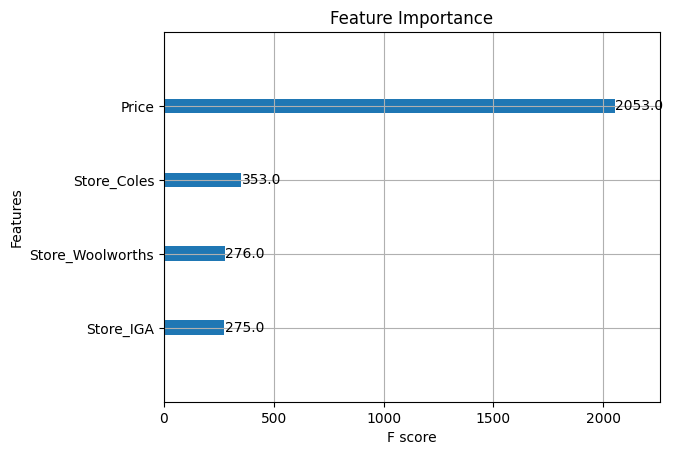

In [50]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Plot feature importance
plot_importance(xgb_model)
plt.title("Feature Importance")
plt.show()


In [51]:
import joblib
joblib.dump(xgb_model, 'xgboost_price_prediction_model.pkl')


['xgboost_price_prediction_model.pkl']